# Analytic Descriptions of the Edge Size Distribution

The purpose of this notebook is to attempt and validate some analytic descriptions of the joint distribution $\mathbb{P}(K_0 = k_0, K_1 = k_1)$, where $K_i$ is the number of nodes on a uniformly random edge sampled from $\mathcal{H}$ as $t\rightarrow \infty$. This problem appears to be quite a bit harder than Phil had originally anticipated, and so what we are able to achieve here is limited. Part of the problem is that there is a LOT of stochasticity in an individual run, which we need to account for. 

Because simulating the full model is expensive, I have coded up a simplified version of the model which replicates the counts of node labels within edges but does not actually track individual nodes. 

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
class ToySimulator:
    
    def __init__(self, edge_list, theta, force_label = None):
        
        self.theta = theta
        self.edge_list = edge_list
        
        self.eta_plus = theta[0]
        self.eta_minus = theta[1]
        self.lambda_plus = theta[2]
        self.lambda_minus = theta[3]
        self.gamma_plus = theta[4]
        self.gamma_minus = theta[5]
        
        self.force_label = force_label
        
    def simulate(self, n_samples):
        
        e_ix = np.random.randint(0, len(self.edge_list), n_samples)
        e = self.edge_list[e_ix[0]]
        
        q = e[0] / (e[0] + e[1])
        
        e_ = [0, 0]
        
        if self.force_label is not None:
            z_u = self.force_label 
        
        else:
            z_u = np.random.choice([0, 1], p = [q, 1-q])
        
        e_[  z_u] += 1 + np.random.binomial(e[z_u] - 1, self.eta_plus)
        e_[1-z_u] +=     np.random.binomial(e[1-z_u],   self.eta_minus)
        
        e_[  z_u] += np.random.poisson(self.lambda_plus  + self.gamma_plus)
        e_[1-z_u] += np.random.poisson(self.lambda_minus + self.gamma_minus)
        
        self.edge_list += [e_]    
    
    def get_joint_counts(self): 
        
        max_1 = max([e[0] for e in self.edge_list])
        max_2 = max([e[1] for e in self.edge_list])
        max_all = max(max_1, max_2)
        
        joint_counts = np.zeros((max_all+1, max_all+1))
        for e in self.edge_list:
            joint_counts[e[0], e[1]] += 1
        
        return joint_counts
    
    def get_proportions(self): 
        k_1 = sum(e[0] for e in self.edge_list)/len(self.edge_list)
        k_2 = sum(e[1] for e in self.edge_list)/len(self.edge_list)
        return k_1, k_2
    
    def get_moments(self, last = None):
        
        if last is None:
            last = 0
        k_1 = [e[0] for e in self.edge_list[-last:]]
        k_2 = [e[1] for e in self.edge_list[-last:]]
        return np.mean(k_1), np.mean(k_2), np.var(k_1), np.var(k_2)
    

For our first experiment, let's consider the sheer variability of behavior between runs. To this end, we'll perform multiple runs of the model and compute as our order parameter the fraction of edges that have more label-1 nodes than label-0 nodes. 

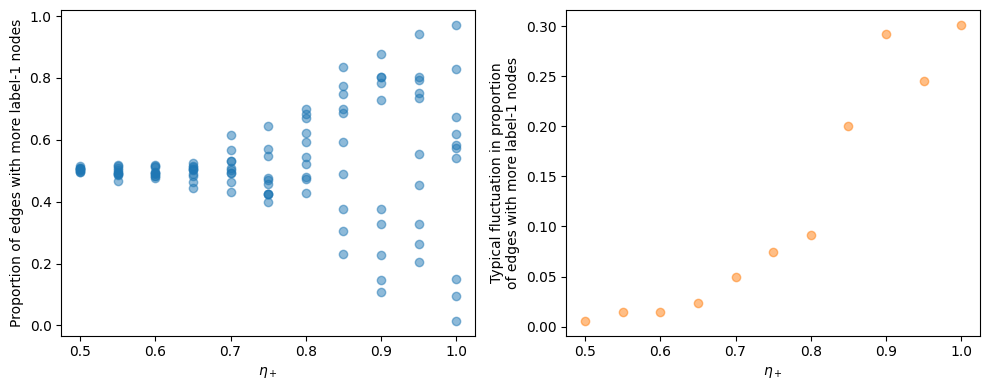

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
A = np.linspace(0.0, 1.0, 11)
THETA = [.5+A/2, .5-A/2, A, 1-A, 0.05, 0.05]

n_reps = 10
n_steps = 10000

for i in range(len(A)):
    
    theta = [THETA[0][i], THETA[1][i], THETA[2][i], THETA[3][i], THETA[4], THETA[5]]
    
    props = []
    
    for _ in range(n_reps):
        
        TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_label = None)
        for _ in range(n_steps):
            TS.simulate(1)
        C = TS.get_joint_counts()
        
        upper_ix = np.arange(C.shape[0])[:, None] > np.arange(C.shape[1])[None, :]
        
        diag_ix = (np.arange(C.shape[0])[:, None] == np.arange(C.shape[1])[None, :])
        
        prop = (C[upper_ix].sum() + C[diag_ix].sum()/2) / C.sum()
        ax[0].scatter(theta[0], prop, color='C0', alpha=0.5)
        
        props += [prop]
    
    ax[1].scatter(theta[0], np.sqrt(np.var(props)), color='C1', alpha=0.5)
        
ax[0].set(xlabel=r'$\eta_+$', ylabel='Proportion of edges with more label-1 nodes')
ax[1].set(xlabel=r'$\eta_+$', ylabel='Typical fluctuation in proportion\nof edges with more label-1 nodes')
        
plt.tight_layout()


There is a high degree of variability in the order parameter, indicating that we are not likely to be able to reason in expectation about the edge size distribution. This likely reflects behavior of Polya-urn type. There may be some hint of phase transitions in these plots, although it is difficult to say without larger simulation runs. It may be desirable to consider different order parameters here. Regardless, it's clear that we are not really going to see a meaningful deterministic description of a stationary edge size distribution. 

## A Mixture Approximation

So, why do we see this extreme variability? And what *can* we say about the structure of the distribution? One apparent insight is that it might, in certain parameter regimes, be pretty reasonable to consider edges to come in two coherent types: edges that are majority label-1 and edges that are majority label-0. We'll refer to these as group 0 edges and group 1 edges, respectively. We'll use the idea that group 0 edges tend to produce other group 0 edges, and group 1 edges tend to produce other group 1 edges. If we followed this logic through, we would expect that the joint distribution of edge sizes would look something like a mixture of two distributions with distinct peaks. This appears to be true in some parameter regimes. 

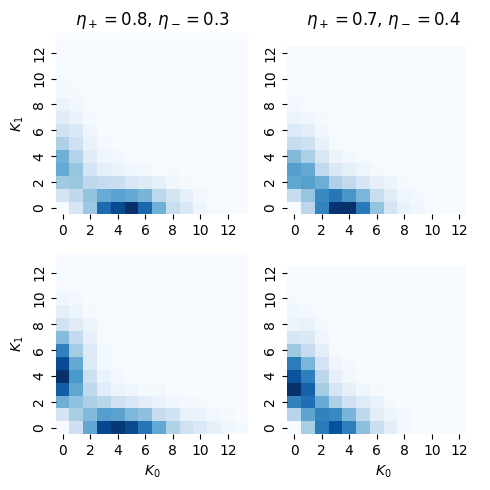

In [22]:
np.random.seed(123)

fig, ax = plt.subplots(2, 2, figsize=(5, 5))
n_steps = 10000

theta_1 = [0.8, 0.3, .8, 0.3, 0.1, 0.1]
theta_2 = [0.7, 0.4, .8, 0.3, 0.1, 0.1]

TS_1 = ToySimulator(edge_list = [[5,5]], theta = theta_1)
TS_2 = ToySimulator(edge_list = [[5,5]], theta = theta_2)
TS_3 = ToySimulator(edge_list = [[5,5]], theta = theta_1)
TS_4 = ToySimulator(edge_list = [[5,5]], theta = theta_2)

for _ in range(n_steps):
    TS_1.simulate(1)
    TS_2.simulate(1)
    TS_3.simulate(1)
    TS_4.simulate(1)

C_0 = TS_1.get_joint_counts()
C_1 = TS_2.get_joint_counts()
C_2 = TS_3.get_joint_counts()
C_3 = TS_4.get_joint_counts()

sns.heatmap(C_0, ax = ax[0,0], cmap='Blues', cbar=False)
ax[0,0].invert_yaxis()
ax[0,0].set(xlim=(0, 14), ylim=(0, 14))

sns.heatmap(C_1, ax = ax[0,1], cmap='Blues', cbar=False)
ax[0,1].invert_yaxis()
ax[0,1].set(xlim=(0, 14), ylim=(0, 14))

sns.heatmap(C_2, ax = ax[1,0], cmap='Blues', cbar=False)
ax[1,0].invert_yaxis()
ax[1,0].set(xlim=(0, 14), ylim=(0, 14))

sns.heatmap(C_3, ax = ax[1,1], cmap='Blues', cbar=False)
ax[1,1].invert_yaxis()
ax[1,1].set(xlim=(0, 14), ylim=(0, 14))

ax[0,0].set(title=r'$\eta_+ = $' + str(theta_1[0]) + ', $\eta_- = $' + str(theta_1[1]))
ax[0,1].set(title=r'$\eta_+ = $' + str(theta_2[0]) + ', $\eta_- = $' + str(theta_2[1]))

ax[1,0].set(xlabel=r'$K_0$', ylabel=r'$K_1$')
ax[1,1].set(xlabel=r'$K_0$')
ax[0,0].set(ylabel=r'$K_1$')

plt.tight_layout()

The visualization above shows the joint distribution for two separate runs for each of two parameter settings. 

A few things to learn from these experiments: 

1. There is indeed a bimodal mixture structure for *some* parameter regimes, probably those in which $\eta_+$ and $\eta_-$ are relatively cleanly separated. When these parameters are less clearly separated, the bimodal structure is less clear. 
2. The amount of mass on each mixture component is stochastic and varies between separate runs. 

If we approximate two populations of edges evolving independently, with each population always choosing the same node label for the seed node, then we can obtain two separate distributions which appear to approximate the components of the mixture reasonably well in at least some parameter regimes.


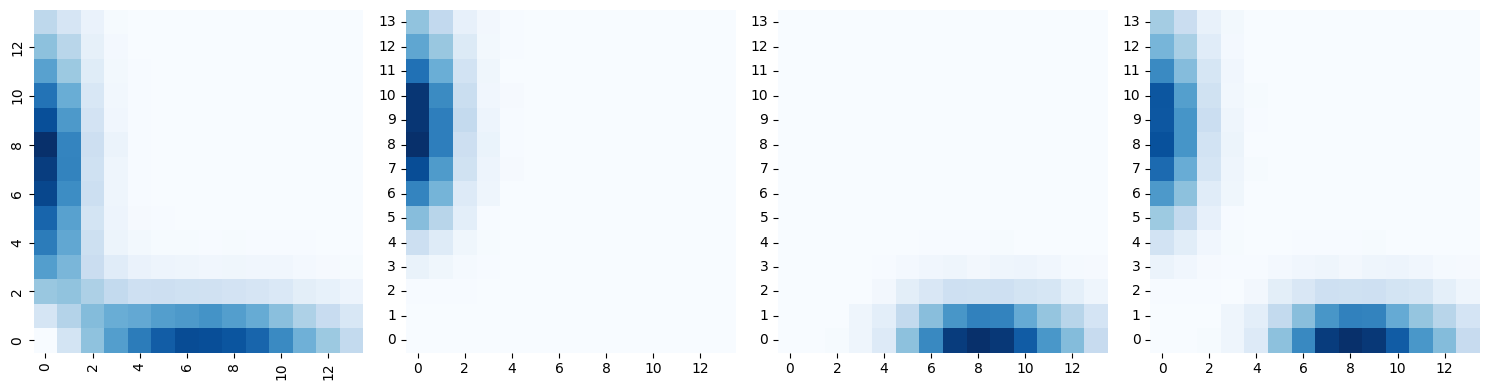

In [23]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

n_steps = 10000

n_reps = 10

theta = [0.9, 0.1, 1.0, 0.5, 0.1, 0.1]


k_max = 30
BIG_C = np.zeros((k_max, k_max))


force_label = None

for _ in range(n_reps):
    TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_label = force_label)
    for _ in range(n_steps):
        TS.simulate(1)
        
    C = TS.get_joint_counts()
    
    if C.shape[0] < k_max:
        C = np.pad(C, ((0, k_max - C.shape[0]), (0, k_max - C.shape[1])), mode='constant')
    
    BIG_C += C

sns.heatmap(BIG_C, ax = ax[0], cmap='Blues', cbar=False)
ax[0].invert_yaxis()

ax[0].set(xlim=(0, 14), ylim=(0, 14))

TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_label = 0)
for _ in range(n_steps):
    TS.simulate(1)
    
C_0 = TS.get_joint_counts()

sns.heatmap(C_0, ax = ax[1], cmap='Blues', cbar=False)
ax[1].invert_yaxis()

ax[1].set(xlim=(0, 14), ylim=(0, 14))

TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_label = 1)
for _ in range(n_steps):
    TS.simulate(1)
    
C_1 = TS.get_joint_counts()

sns.heatmap(C_1, ax = ax[2], cmap='Blues', cbar=False)
ax[2].invert_yaxis()

ax[2].set(xlim=(0, 14), ylim=(0, 14))

k_max = max(C_0.shape[0], C_1.shape[0])

C_0 = np.pad(C_0, ((0, k_max - C_0.shape[0]), (0, k_max - C_0.shape[1])), mode='constant')
C_1 = np.pad(C_1, ((0, k_max - C_1.shape[0]), (0, k_max - C_1.shape[1])), mode='constant')

sns.heatmap(C_0+C_1, ax = ax[3], cmap='Blues', cbar=False)

ax[3].invert_yaxis()

ax[3].set(xlim=(0, 14), ylim=(0, 14))


plt.tight_layout()

Since we can't reasonably predict the mixture weights and we also can't really separate out the mixture components in a principled way, one thing we can do to compare this approximation to the realized distribution is to symmetrize: we can force the simulated distribution to have weights $\pi_1 = \pi_2 = 0.5$ by computing $P'(K_1, K_2) = \frac{1}{2} P(K_1, K_2) + \frac{1}{2} P(K_2, K_1)$, where $P$ is the original distribution and $P'$ is the symmetrized distribution. Below, we conduct this comparison between the evenly-weighted mixture approximation on the one hand and the symmetrized simulation on the other: 

In [24]:

n_steps = 1000000

k_max = 70
n_reps = 1

MU_EXACT = []
MU_APPROX = []
V_EXACT = []
V_APPROX = []

ETA_PLUS = []

A = np.linspace(0.0, 1.0, 11)

THETA = [.5+A/2, .5-A/2, A, 1-A, 0.05, 0.05]

for i in range(len(A)):
    
    theta = [THETA[0][i], THETA[1][i], THETA[2][i], THETA[3][i], THETA[4], THETA[5]]
        
    for _ in range(n_reps):
        
        #------
        # actual simulation
        #------
        
        big_C = np.zeros((k_max, k_max))
        
        TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_label = None)
        for _ in range(n_steps):
            TS.simulate(1)
        C = TS.get_joint_counts()
        
        if C.shape[0] < k_max:
            C = np.pad(C, ((0, k_max - C.shape[0]), (0, k_max - C.shape[1])), mode='constant')
        
        big_C += C
        
        
        #------
        # approximations with no interaction 
        #------
        big_C0 = np.zeros((k_max, k_max))
        TS = ToySimulator(edge_list = [[5,5]], theta = theta, force_label = 0)
        for _ in range(n_steps):
            TS.simulate(1)
        C0 = TS.get_joint_counts()
        
        if C0.shape[0] < k_max:
            C0 = np.pad(C0, ((0, k_max - C0.shape[0]), (0, k_max - C0.shape[1])), mode='constant')
        
        big_C0 += C0
        
        
    big_C += big_C.T # symmetrize, now the mixture question is moot
    big_C = big_C / big_C.sum()
    
    big_C0 += big_C0.T # symmetrize, now the mixture question is moot
    big_C0 = big_C0 / big_C0.sum()
    
    
    p_K_0_exact = big_C.sum(axis=1)
    
    MU_EXACT.append(np.sum(p_K_0_exact* np.arange(len(p_K_0_exact))))
    V_EXACT.append(np.sum(p_K_0_exact* np.arange(len(p_K_0_exact))**2) - MU_EXACT[-1]**2)
    
    p_K_0_approx = big_C0.sum(axis=1)
    
    MU_APPROX.append(np.sum(p_K_0_approx* np.arange(len(p_K_0_approx))))
    V_APPROX.append(np.sum(p_K_0_approx* np.arange(len(p_K_0_approx))**2) - MU_APPROX[-1]**2)

KeyboardInterrupt: 

Let's now also compute the analytic approximations for the two mixture components and compare them to the symmetrized simultaion. 

/tmp/ipykernel_2302774/1786935940.py:6: RuntimeWarning: divide by zero encountered in divide
  EK_1 = (1 + THETA[2] + THETA[4] - THETA[0]) / (1 - THETA[0])
/tmp/ipykernel_2302774/1786935940.py:15: RuntimeWarning: invalid value encountered in multiply
  VK_1 = (THETA[0]*(1-THETA[0])*EK_1 - THETA[0]*(1-THETA[0]) +  THETA[2] + THETA[4]) / (1 - THETA[0]**2)


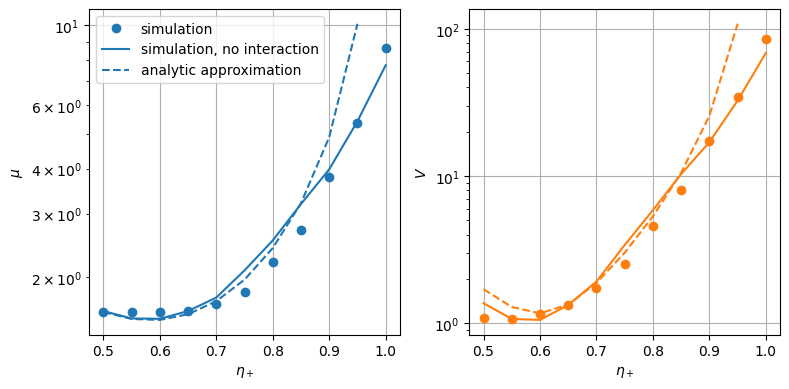

In [ ]:
# ANALYTIC APPROXIMATIONS

# analytic mean 

EK_0 = (THETA[3] + THETA[5]) / (1 - THETA[1])
EK_1 = (1 + THETA[2] + THETA[4] - THETA[0]) / (1 - THETA[0])

# law of total expectation
MU_ANALYTIC = (EK_0 + EK_1)/2

# analytic variance, using law of total variance on mixture
# these components come from using the law of total variance on an update in the simplified model variant. 

VK_0 = (THETA[1]*EK_0 + THETA[3] + THETA[5]) / (1 - THETA[1]**2)
VK_1 = (THETA[0]*(1-THETA[0])*EK_1 - THETA[0]*(1-THETA[0]) +  THETA[2] + THETA[4]) / (1 - THETA[0]**2) 

# law of total variance
V_ANALYTIC = (VK_0 + VK_1)/2 + (EK_0 - EK_1)**2/4


fig, ax = plt.subplots(1, 2, figsize=(8, 4))    
ax[0].plot(THETA[0], MU_EXACT, 'o', color='C0', label = "simulation")
ax[0].plot(THETA[0], MU_APPROX,  color='C0', label = "simulation, no interaction")
ax[0].plot(THETA[0], MU_ANALYTIC, "--",  color='C0', label = "analytic approximation")

ax[1].plot(THETA[0], V_EXACT, 'o', color='C1')
ax[1].plot(THETA[0], V_APPROX,  color='C1')
ax[1].plot(THETA[0], V_ANALYTIC, "--",  color='C1')
    
ax[0].set(xlabel=r'$\eta_+$', ylabel=r'$\mu$')
ax[1].set(xlabel=r'$\eta_+$', ylabel=r'$V$')

for i in range(2):
    ax[i].semilogy()
    ax[i].grid()

ax[0].legend()

plt.tight_layout()

We observe that the estimates are pretty fair (with this one-dimensional parameterization) for roughly $\eta \leq 0.8$, after which the approximation begins to degrade. Perhaps notably, $\eta \approx 0.8$ is also where we begin to see the emergence of persistent majorities/minorities within the edges. It may be that there is some kind of interesting phase transition around there. 

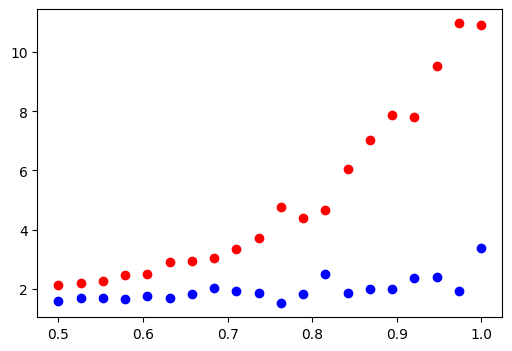

In [ ]:
A = np.linspace(0.5, 1, 20)

n_reps = 10

fig, ax = plt.subplots(1, 1, figsize = (6,4))

for a in A:
    
    K_1 = []
    K_2 = []
    
    for _ in range(n_reps):
        
        TS = ToySimulator(edge_list = [[5,5]], theta = [0.5+a/2, 0.5-a/2, a, 1-a, 0.05, 0.05])
        for _ in range(10000):
            TS.simulate(1)
        k_1, k_2 = TS.get_proportions()
        k_1, k_2 = sorted([k_1, k_2])
        K_1 += [k_1]
        K_2 += [k_2]
        
    k_1 = np.mean(K_1)
    k_2 = np.mean(K_2)
    ax.plot(a, k_1, 'bo')
    ax.plot(a, k_2, 'ro')